# Práctica de aprendizaje automático (parte 3)

Entrega este cuaderno habiendo **ejecutado todas las celdas**. Incluye en la entrega **todos los ficheros necesarios para su ejecución**.

Asegúrate de que la presentación está bien estructurada: Se valorará la **claridad, concisión, y completitud** del informe.

Se trata de una práctica abierta: **sé intrépido y explora**. 

1. Describe las características de los datos:
    * Tipo de datos (e.g. [https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)](https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)))
    * Número de ejemplos de cada una de las clases.
    * Número y tipo (nominales no ordenados, nominales ordenados, numéricos) de atributos.

Esta información se debería utilizar en el análisis; por ejemplo, si se selecciona un atributo para la predicción, ¿es clara su relevancia por el tipo de información que proporciona de acuerdo con nuestro conocimiento experto sobre el área?
    
2. Detalla la metodología utilizada:
    * Partitición de los datos: tamaño de los conjuntos de entrenamiento y test, uso de estratificación en el muestreo.
    * Preprocesamiento: condificación de los atributos, construcción y selección de características, normalización, etc. (¡solo se debe utilizar la información del consjunto de entrenamiento!)
    * Determinación de los hiperparámetros; por ejemplo, mediante búsqueda en rejilla y validación cruzada.
    * Estimación del error de generalización y su incertidumbre.
2. Resume los resultados en gráficas y tablas.
3. Elabora esta información e ilustra tus observaciones con los resultados obtenidos.
4. Proprociona una recomendación final:
    * Tipo de clasificador.
    * Configuración del clasificador (arquitectura, hiperparámetros, etc.) y método de entrenamiento (función de coste, método de optimización, uso de técnicas de regularización,...)
    * para el predictor final, proporciona los errores de entrenamiento, validación cruzada y test.
5. Resume las conclusiones del análisis.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report


## 3. Procesamiento de texto y datos no balanceados (3 puntos)

In [2]:
df = pd.read_csv("train.tsv", sep='\t', index_col="PhraseId")
pd.set_option('display.max_colwidth', None)
df.head(2)

,SentenceId,Phrase,Sentiment
PhraseId,,,
1,1,"A series of escapades demonstrating the adage that what is good for the goose is also good for the gander , some of which occasionally amuses but none of which amounts to much of a story .",1
2,1,A series of escapades demonstrating the adage that what is good for the goose,2


Este conjunto de datos que usaremos ahora permite aprender el sentimiento del texto a partir de frases etiquetadas.
Las etiquetas para los sentimientos son:

* 0 - negative
* 1 - somewhat negative
* 2 - neutral
* 3 - somewhat positive
* 4 - positive

Más información [aquí](https://www.kaggle.com/c/sentiment-analysis-on-movie-reviews).


A lo largo de este ejercicio veremos distintas formas de procesar el texto y de equilibrar las clases a aprender.

In [3]:
train, test = train_test_split(df[["Phrase", "Sentiment"]], random_state=0)
X_train = train.Phrase
X_test = test.Phrase
y_train = train.Sentiment
y_test = test.Sentiment

**Modelos básicos**

Vamos a comenzar con una concatenación (*pipe*) de modelos muy básicos y analizaremos si tienen algún problema.

In [4]:
count_vectorizer = CountVectorizer(max_features=1000)
decision_tree = DecisionTreeClassifier(criterion='entropy', max_depth=2)
pipe = make_pipeline(count_vectorizer,decision_tree)

In [5]:
def get_accuracy(pipe):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    return round(accuracy_score(y_pred, y_test),3)

In [6]:
get_accuracy(pipe)

0.515

Veamos qué clases se están prediciendo de verdad

In [7]:
# Etiquetas de entrenamiento
round(pd.Series(y_train).value_counts(normalize=True),2)

Sentiment
2    0.51
3    0.21
1    0.17
4    0.06
0    0.04
Name: proportion, dtype: float64

In [8]:
# Clases en predicción
y_pred = pipe.predict(X_test)
round(pd.Series(y_pred).value_counts(normalize=True),2)

2    0.97
3    0.03
Name: proportion, dtype: float64

Es decir: al ser un problema no balanceado, la predicción está claramente sesgada hacia una de las clases.

Esto se puede ver también analizando la **matriz de confusión**

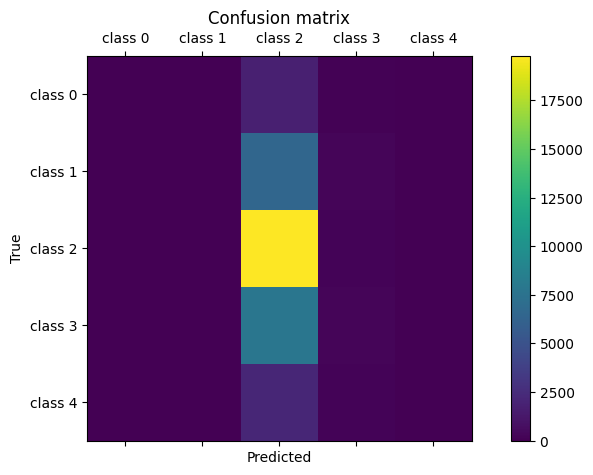

In [9]:
def plot_confusion_matrix(pipe):
    ticks = np.unique(y_test)
    labels = [('class '+ str(tick)) for tick in ticks]
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(111)
    cax = ax.matshow(cm)
    plt.title('Confusion matrix')
    fig.colorbar(cax)
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)
    ax.set_yticks(ticks)
    ax.set_yticklabels(labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

plot_confusion_matrix(pipe)

## Cambio de modelos y procesamiento de los datos

Analiza si algún otro modelo de los vistos en ejercicios anteriores evita este problema de las clases desbalanceadas.

Por ejemplo, en la celda siguiente se cambia el árbol de decisión por un KNN.

In [10]:
knn = KNeighborsClassifier(n_neighbors=1)
pipe_knn = make_pipeline(count_vectorizer,knn)
get_accuracy(pipe_knn)

0.469

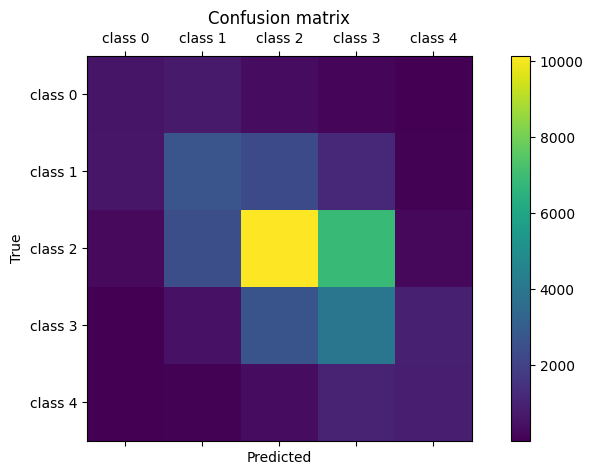

In [11]:
plot_confusion_matrix(pipe_knn)

### Explora varios modelos y responde:

* ¿Con qué modelo se obtienen mejores resultados?
* ¿Hay algún parámetro de los modelos que sea particularmente efectivo en evitar el desbalanceo?

Nota: incluye tantas celdas como precises para enseñar el código que has usado para responder a estas preguntas.

,,,

El conjunto de datos utilizado corresponde a frases de reseñas de películas etiquetadas según su sentimiento.
Cada ejemplo consiste en:

- Un atributo textual (`Phrase`), que contiene una frase en lenguaje natural.
- Una etiqueta categórica ordinal (`Sentiment`) con 5 clases:
  - 0: negative
  - 1: somewhat negative
  - 2: neutral
  - 3: somewhat positive
  - 4: positive

El conjunto contiene aproximadamente 150.000 ejemplos, con una distribución claramente desbalanceada entre clases,
siendo las clases intermedias (1 y 3) mayoritarias frente a las clases extremas (0 y 4).

El atributo es de tipo textual no estructurado, por lo que requiere técnicas de vectorización para poder ser utilizado
por modelos de aprendizaje automático.


A continuación se procede a estudiar los métodos de regresión logística, redes neuronales y métodos de núcleos. 

In [12]:
log_reg = LogisticRegression(
    max_iter=200,
    solver="lbfgs"
)

pipe_logreg = make_pipeline(count_vectorizer, log_reg)
get_accuracy(pipe_logreg)


0.589

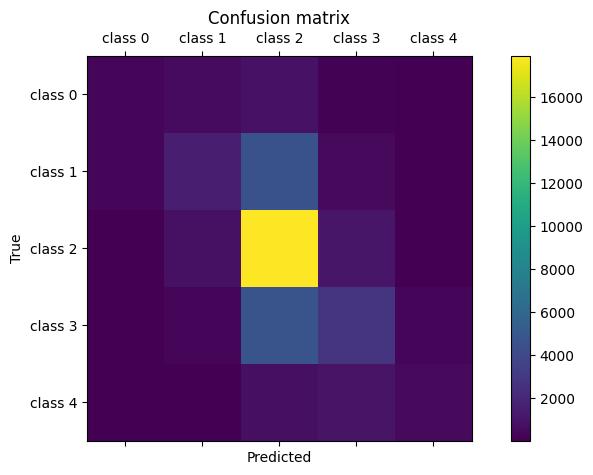

In [13]:
plot_confusion_matrix(pipe_logreg)


In [14]:
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation="relu",
    solver="adam",
    max_iter=20,
    random_state=0
)

pipe_mlp = make_pipeline(count_vectorizer, mlp)
get_accuracy(pipe_mlp)


c:\Users\Usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.622

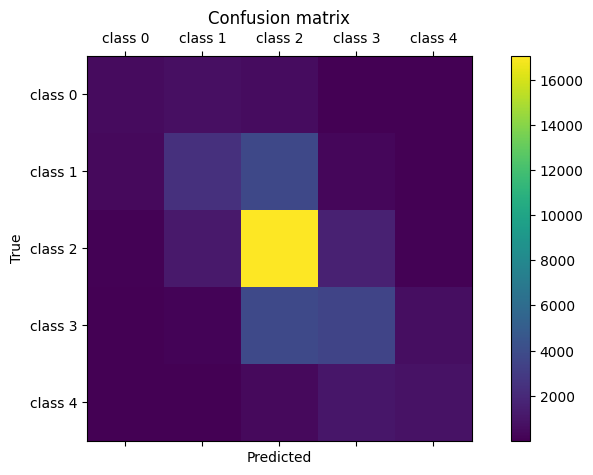

In [15]:
plot_confusion_matrix(pipe_mlp)


In [16]:
svm_linear = LinearSVC(
    class_weight="balanced",
    random_state=0,
    max_iter=2000
)

pipe_svm = make_pipeline(count_vectorizer, svm_linear)
get_accuracy(pipe_svm)


0.561

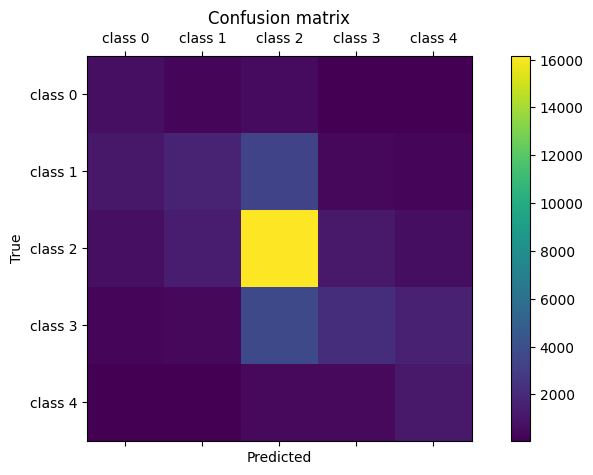

In [17]:
plot_confusion_matrix(pipe_svm)


Aunque se probó inicialmente una SVM con núcleo RBF, su coste computacional resultó prohibitivo debido a la alta dimensionalidad generada por el procesamiento de texto. Por ello, se optó por una SVM con núcleo lineal, que es el enfoque habitual en problemas de clasificación de texto y ofrece un excelente "tradeoff" entre rendimiento y eficiencia.


In [18]:
decision_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=2,
    random_state=0
)

pipe_tree = make_pipeline(count_vectorizer, decision_tree)


El clasificador KNN presenta un coste computacional elevado en espacios de alta dimensionalidad, por lo que no se incluye en la comparación final.


In [19]:
models = {
    "Decision Tree": pipe_tree,
    "Logistic Regression": pipe_logreg,
    "Neural Network (MLP)": pipe_mlp,
    "SVM (Linear)": pipe_svm
}

results = {
    name: get_accuracy(model)
    for name, model in models.items()
}

pd.DataFrame.from_dict(results, orient="index", columns=["Accuracy"])


c:\Users\Usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


,Accuracy
Decision Tree,0.515
Logistic Regression,0.589
Neural Network (MLP),0.622
SVM (Linear),0.561


A partir de los resultados obtenidos, el modelo que presenta el mejor rendimiento en términos de accuracy es la red neuronal multicapa (MLP), seguida de la regresión logística. No obstante, la m ejor alternativa lineal es la regresión logística, con una precisión del 58.9%, destacando por su simplicidad, interpretabilidad y menor coste computacional. Los modelos de árboles de decisión y SVM lineales presentan resultados peores, posiblemente debido a su menor capacidad de generalización en espacios de alta dimensionalidad.

En resumen, el procesamiento de texto da lugar a espacios de características de alta dimensionalidad, lo que supone un reto para ciertos modelos clásicos. Existen diferencias significativas de rendimiento entre modelos, lo que pone de manifiesto la importancia de comparar distintos enfoques. Por un lado, los modelos lineales ofrecen resultados competitivos con un coste computacional reducido y buena interpretabilidad. POr otro lado, las redes neuronales muestran una mayor capacidad de adaptación a patrones complejos y no lineales (además logran el mejor rendimiento en este análisis). Finalmente, modelos como árboles de decisión o SVM lineales pueden verse limitados.

A continuación, se divide el conjunto de datos en entrenamiento (75%) y test (25%), utilizando muestreo estratificado
para preservar la distribución original de clases. Se fija una semilla aleatoria (`random_state=0`) para garantizar la reproducibilidad de los resultados.


In [20]:
# Train / Test estratificado
train, test = train_test_split(
    df[["Phrase", "Sentiment"]],
    test_size=0.25,
    random_state=0,
    stratify=df["Sentiment"]
)

X_train = train.Phrase
X_test = test.Phrase
y_train = train.Sentiment
y_test = test.Sentiment


In [21]:
# Función de evaluación común (orientada a desbalanceo)
def evaluate_model(pipe, name):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro-F1": f1_score(y_test, y_pred, average="macro")
    }


In [22]:
vectorizer = CountVectorizer(
    max_features=1000,
    ngram_range=(1,1) 
)

# Se fija TF-IDF/Count unigramas para aislar el efecto del clasificador

models = [
    ("LogReg (no weight)",
     make_pipeline(
         vectorizer,
         LogisticRegression(max_iter=200)
     )),
    
    ("LogReg (balanced)",
     make_pipeline(
         vectorizer,
         LogisticRegression(max_iter=200, class_weight="balanced")
     )),
    
    ("Linear SVM (no weight)",
     make_pipeline(
         vectorizer,
         LinearSVC(max_iter=2000)
     )),
    
    ("Linear SVM (balanced)",
     make_pipeline(
         vectorizer,
         LinearSVC(class_weight="balanced", max_iter=2000)
     ))
]


Para aislar el efecto del clasificador, se fija el mismo vectorizador en todos los modelos.

Dado el fuerte desbalanceo entre clases, la métrica principal utilizada es el macro-F1, ya que penaliza el mal rendimiento en clases minoritarias. La accuracy se incluye únicamente como métrica complementaria.


In [23]:
results = []

for name, model in models:
    results.append(evaluate_model(model, name))

results_df = pd.DataFrame(results).sort_values("Macro-F1", ascending=False)
results_df


,Model,Accuracy,Macro-F1
3,Linear SVM (balanced),0.557991,0.413453
1,LogReg (balanced),0.509753,0.404304
0,LogReg (no weight),0.587159,0.395513
2,Linear SVM (no weight),0.575061,0.352859


In [24]:
best_model = make_pipeline(
    vectorizer,
    LinearSVC(class_weight="balanced", max_iter=2000)
)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.24      0.40      0.30      1768
           1       0.43      0.24      0.31      6818
           2       0.66      0.81      0.73     19896
           3       0.49      0.26      0.34      8232
           4       0.31      0.49      0.38      2301

    accuracy                           0.56     39015
   macro avg       0.43      0.44      0.41     39015
weighted avg       0.55      0.56      0.54     39015



In [25]:
confusion_matrix(y_test, y_pred)


array([[  703,   362,   528,    85,    90],
       [ 1063,  1664,  3430,   414,   247],
       [  703,  1252, 16113,  1195,   633],
       [  335,   464,  3761,  2174,  1498],
       [   76,    88,   483,   538,  1116]])

Mejor modelo: La SVM lineal con `class_weight="balanced"` obtiene el mayor valor de macro-F1 y muestra un desempeño significativamente más equilibrado en las clases minoritarias, evitando el colapso hacia la clase mayoritaria.

Parámetros más efectivos contra el desbalanceo: La ponderación de clases (`class_weight="balanced"`) es el factor más determinante. En ambos modelos lineales (Logistic Regression y Linear SVM) mejora de forma consistente el recall y la precisión de las clases minoritarias, incrementando el macro-F1 frente a las versiones sin ponderación.

Conclusión: En clasificación de texto con clases desbalanceadas, los modelos lineales con ponderación de clases ofrecen una solución robusta, eficiente y bien alineada con métricas orientadas a equidad entre clases. Se recomienda por tanto utilizar una SVM lineal con ponderación de clases (`class_weight="balanced"`) como predictor final. Este modelo ofrece el mejor compromiso entre rendimiento global (macro-F1), comportamiento equilibrado entre clases y eficiencia computacional en espacios de alta dimensionalidad.

---

### Procesamiento de los datos

El primer paso que se usó en el *pipe* anterior es muy simple: sólo cuenta cuántas veces aparece cada término. Además, se ha limitado a un máximo de 1000 dimensiones. Prueba otras formas de procesar el texto y discute las diferencias. 

Como ejemplo, en la celda siguiente se usa un método que considera la frecuencia de los términos ([TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)). La documentación muestra que permite varias configuraciones (eliminar acentos, pasar a minúsculas, realizar otras transformaciones más complejas, quitar palabras comunes, etc.).

0.605


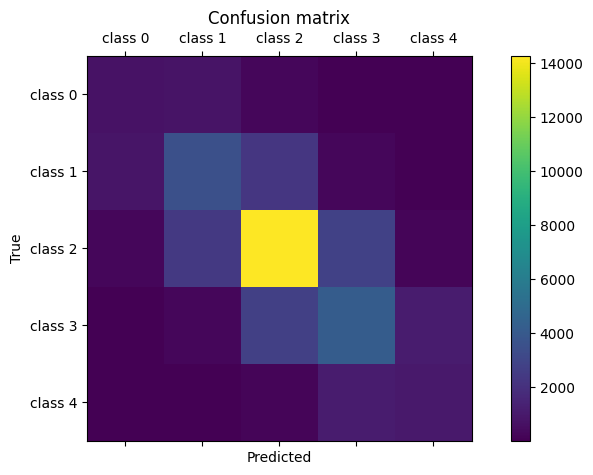

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
# tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,3))
pipe_tfidf = make_pipeline(tfidf_vectorizer, knn)
print(get_accuracy(pipe_tfidf))
plot_confusion_matrix(pipe_tfidf)

Realiza pruebas con varios clasificadores y configuraciones para el procesamiento de texto y contesta:

* De acuerdo con tus experimentos, ¿afecta más cambiar el clasificador o cómo se procesa el texto?
* ¿Has encontrado algún tipo de procesamiento que siempre mejore los resultados? ¿En qué hipótesis te has basado para probarlo?

In [27]:
# incluye aquí tu código

## Conclusiones.
Resume los resultados y conclusiones del estudio que has realizado.
[POR HACER]
